# Predicting Premier League Transfer Value Growth

Goal: for each player currently valued in the Premier League, predict how much their transfer market value will change over the next 3, 6, 9, and 12 months, and rank who's projected to rise the most.

Approach: build a panel of historical valuation "snapshots" (one row per past valuation event) with trailing-365-day performance features and the player's own valuation trajectory known as of that date, and a forward-looking value-change target at each horizon (the nearest actual future valuation). Train a linear baseline, Ridge, Lasso, and XGBoost per horizon, then apply the best model to each player's most recent snapshot to generate forward-looking predictions, with a quantile-regression range around each one.

Notebook 05 checks this whole pipeline walk-forward across nine years of cutoffs; the defaults used here (log-ratio target, value-trend features) are the ones that won there.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.panel import HORIZONS_MONTHS, build_snapshot_panel
from src.modeling import (
    fit_quantile_models,
    latest_snapshot_per_player,
    modelable_rows,
    predict_value_growth,
    predict_value_growth_interval,
    train_horizon_models,
)

sns.set_theme(style="whitegrid")
USD_PER_EUR = 1.08  # same fixed rate used in 01_eda.ipynb, for readability only

panel = build_snapshot_panel()
panel.shape

(33748, 55)

## Target coverage by horizon

Not every snapshot has a matched future valuation within tolerance (this dataset re-values players roughly every 150-190 days on average), so the 3-month horizon has noticeably fewer usable rows than the others.

In [2]:
coverage = pd.DataFrame(
    {
        "months": HORIZONS_MONTHS,
        "rows_with_target": [panel[f"value_change_{m}m_pct"].notna().sum() for m in HORIZONS_MONTHS],
        "pct_of_panel": [round(panel[f"value_change_{m}m_pct"].notna().mean() * 100, 1) for m in HORIZONS_MONTHS],
    }
)
coverage

,months,rows_with_target,pct_of_panel
0,3,9088,26.9
1,6,26176,77.6
2,9,28625,84.8
3,12,28490,84.4


## Target distribution by horizon

Value change is heavily right-skewed at every horizon (a few breakout players multiply their value many times over) with a spike at 0% (many snapshots simply aren't re-valued within the window). The x-axis below is clipped to ±200% for readability.

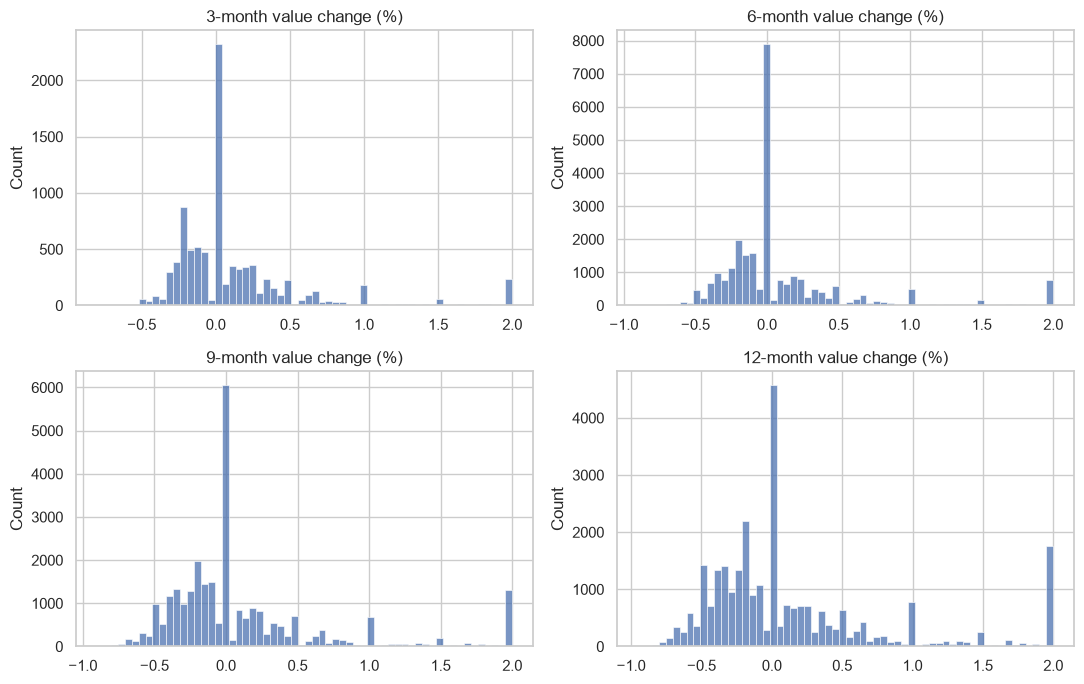

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, months in zip(axes.flat, HORIZONS_MONTHS):
    col = f"value_change_{months}m_pct"
    data = panel[col].dropna().clip(-2, 2)
    sns.histplot(data, bins=60, ax=ax)
    ax.set_title(f"{months}-month value change (%)")
    ax.set_xlabel(None)
plt.tight_layout()
plt.show()

## Modeling approach

For each horizon, train the same set of regressors on the same features:

- **Features**: log10(current value), age, age² (captures the peak-then-decline age curve from the EDA notebook), trailing goals/assists per-90, trailing minutes, trailing appearances, trailing average league position of the player's club (team-strength context), months since last transfer, number of prior transfers, log(last transfer fee), sub-position, preferred foot, plus the player's **valuation trajectory** (log of the last re-valuation ratio, months since it, and current value as a share of the career peak so far) and the **club's standing** as of the snapshot (league position after its latest match, how far through the season, and whether it sits in the relegation zone).
- **Models**: `LinearRegression` (baseline), `Ridge`, `Lasso`, `XGBRegressor` with squared error and with a pseudo-Huber loss.
- **Target**: the model fits `log(future value / current value)` rather than the raw % change, and predictions are converted back to % change. Value change is heavily right-skewed; the log ratio is symmetric in up/down moves and stops a few breakouts from dominating the loss. Notebook 05 shows this fixes the model's tendency to mis-size moves. The % target is additionally capped at [-95%, +500%] before fitting.
- **Split**: time-based (train on earlier snapshots, test on the most recent 20%) so the model is evaluated on genuinely future data, not a random shuffle that would leak information across a player's own history.

Note: `players.csv` also has `contract_expiration_date` and international caps/goals, but those are current-as-of-scrape snapshots rather than dated historical series — using them on old valuation rows would leak future information into the past, so they're excluded from the model. Contract expiry *is* shown next to each prediction below as context, where it is genuinely current. The transfer-history and club-position features above come from genuinely dated tables (`transfers.csv`, `games.csv`) instead.

In [4]:
all_results = {months: train_horizon_models(panel, months) for months in HORIZONS_MONTHS}

metrics = pd.DataFrame(
    [
        {"months": months, "model": name, **{k: v for k, v in r.items() if k != "pipeline"}}
        for months, results in all_results.items()
        for name, r in results.items()
    ]
)
metrics.sort_values(["months", "mae"])

,months,model,best_params,mae,rmse,r2,n_train,n_test
4,3,xgboost_huber,{},0.184187,0.446360,0.310497,7288,1799
3,3,xgboost,{},0.186637,0.448321,0.304424,7288,1799
1,3,ridge,{},0.198171,0.466665,0.246340,7288,1799
0,3,linear,{},0.198203,0.466633,0.246443,7288,1799
2,3,lasso,{},0.199474,0.474957,0.219317,7288,1799
9,6,xgboost_huber,{},0.246056,0.506449,0.250352,20933,5234
8,6,xgboost,{},0.248117,0.504062,0.257400,20933,5234
7,6,lasso,{},0.258360,0.528519,0.183593,20933,5234
6,6,ridge,{},0.261244,0.524062,0.197303,20933,5234
5,6,linear,{},0.261253,0.524042,0.197365,20933,5234


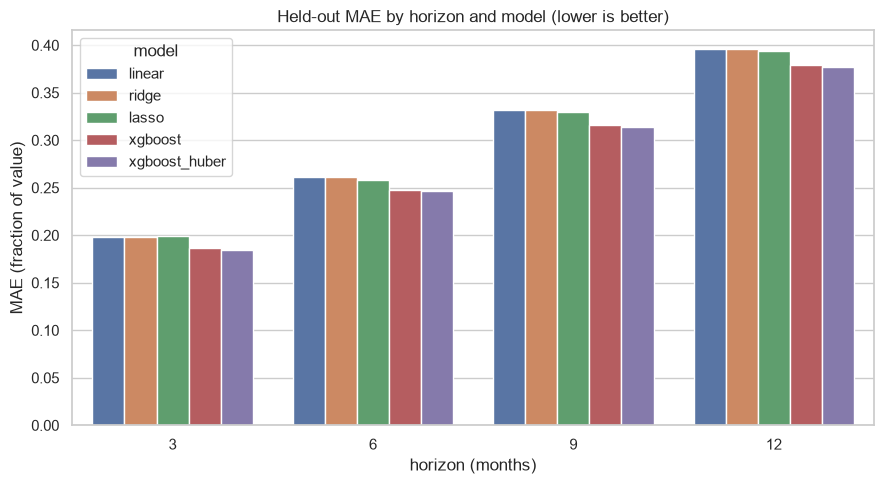

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=metrics, x="months", y="mae", hue="model", ax=ax)
ax.set_title("Held-out MAE by horizon and model (lower is better)")
ax.set_xlabel("horizon (months)")
ax.set_ylabel("MAE (fraction of value)")
plt.tight_layout()
plt.show()

The gaps between models are small on this same-period split, and the ranking can flip between horizons. Notebook 05 is the better place to compare them: walk-forward across 16 cutoffs, XGBoost has the best-calibrated move sizes while all four rank players about equally well. Here we simply use the best model per horizon (by MAE) for the forward-looking predictions below.

## Predicted top value-risers

Applying each horizon's best model to every player's most recent valuation snapshot (within the last 12 months). **Caveats**: this only knows about age, position, on-pitch performance, and the player's own valuation history — it has no signal on injuries, transfer rumors, or club form, and very young/low-minutes players can produce large predicted swings off a small base, so treat these as a data-driven starting point rather than a forecast. `months_to_contract_expiry` is shown for context (an expiring deal often moves a valuation), not used by the model; it's blank where the dataset has no contract on record.

In [6]:
best_model_per_horizon = {
    months: min(results, key=lambda name: results[name]["mae"]) for months, results in all_results.items()
}
best_model_per_horizon

{3: 'xgboost_huber',
 6: 'xgboost_huber',
 9: 'xgboost_huber',
 12: 'xgboost_huber'}

In [7]:
latest = latest_snapshot_per_player(panel)

all_preds = {}
top_risers_pct = {}
for months in HORIZONS_MONTHS:
    best_name = best_model_per_horizon[months]
    pipeline = all_results[months][best_name]["pipeline"]
    preds = predict_value_growth(pipeline, latest)
    preds["current_value_usd_m"] = preds["current_value_eur"] * USD_PER_EUR / 1_000_000
    preds["predicted_value_usd_m"] = preds["predicted_value_eur"] * USD_PER_EUR / 1_000_000
    preds["predicted_eur_change_usd_m"] = preds["predicted_eur_change"] * USD_PER_EUR / 1_000_000
    all_preds[months] = preds
    top_risers_pct[months] = preds.sort_values("predicted_pct_change", ascending=False).head(10)

display_cols = ["name", "sub_position", "age", "current_value_usd_m", "predicted_pct_change", "predicted_value_usd_m", "months_to_contract_expiry"]
for months in HORIZONS_MONTHS:
    print(f"=== Top predicted risers by % change: next {months} months (model: {best_model_per_horizon[months]}) ===")
    display(top_risers_pct[months][display_cols].round(2))

=== Top predicted risers by % change: next 3 months (model: xgboost_huber) ===


,name,sub_position,age,current_value_usd_m,predicted_pct_change,predicted_value_usd_m,months_to_contract_expiry
33400,Charlie Crew,Defensive Midfield,19.97,0.16,1.37,0.38,24.90
33350,Rio Cardines,Left-Back,19.92,0.32,1.01,0.65,24.90
32227,Sam Curtis,Right-Back,20.01,0.19,0.98,0.37,5.88
33569,Alex Cairns,Goalkeeper,33.41,0.05,0.98,0.11,24.90
33420,Harrison Jones,Attacking Midfield,21.44,0.16,0.79,0.29,36.89
33125,Nik Tzanev,Goalkeeper,29.38,0.11,0.76,0.19,1.61
33121,Ronan Kpakio,Right-Back,18.97,1.30,0.76,2.27,37.61
33348,Chido Obi,Centre-Forward,18.51,5.40,0.75,9.46,NaN
32233,Ben Nelson,Centre-Back,21.71,0.65,0.74,1.13,18.86
33130,James Carragher,Centre-Back,23.50,0.27,0.74,0.47,13.60


=== Top predicted risers by % change: next 6 months (model: xgboost_huber) ===


,name,sub_position,age,current_value_usd_m,predicted_pct_change,predicted_value_usd_m,months_to_contract_expiry
32227,Sam Curtis,Right-Back,20.01,0.19,1.43,0.46,5.88
33400,Charlie Crew,Defensive Midfield,19.97,0.16,1.03,0.33,24.90
33355,Mohamadou Kanté,Defensive Midfield,20.70,1.08,1.01,2.17,60.87
33350,Rio Cardines,Left-Back,19.92,0.32,0.88,0.61,24.90
33391,Max Dowman,Right Winger,16.42,32.40,0.76,57.02,NaN
33382,Rio Ngumoha,Left Winger,17.76,32.40,0.74,56.22,24.90
32226,Louie Marsh,Second Striker,21.42,0.16,0.68,0.27,30.88
33125,Nik Tzanev,Goalkeeper,29.38,0.11,0.68,0.18,1.61
32212,Ishé Samuels-Smith,Left-Back,19.50,0.76,0.68,1.27,66.85
31838,Callum Jones,Central Midfield,24.24,0.16,0.66,0.27,23.00


=== Top predicted risers by % change: next 9 months (model: xgboost_huber) ===


,name,sub_position,age,current_value_usd_m,predicted_pct_change,predicted_value_usd_m,months_to_contract_expiry
32227,Sam Curtis,Right-Back,20.01,0.19,1.58,0.49,5.88
33400,Charlie Crew,Defensive Midfield,19.97,0.16,1.20,0.36,24.90
33355,Mohamadou Kanté,Defensive Midfield,20.70,1.08,1.07,2.24,60.87
33135,Tammer Bany,Centre-Forward,22.61,0.27,0.99,0.54,25.10
31838,Callum Jones,Central Midfield,24.24,0.16,0.83,0.30,23.00
32163,Mark O'Mahony,Centre-Forward,20.87,0.49,0.83,0.89,6.11
33350,Rio Cardines,Left-Back,19.92,0.32,0.80,0.58,24.90
33121,Ronan Kpakio,Right-Back,18.97,1.30,0.80,2.33,37.61
32212,Ishé Samuels-Smith,Left-Back,19.50,0.76,0.80,1.36,66.85
32226,Louie Marsh,Second Striker,21.42,0.16,0.74,0.28,30.88


=== Top predicted risers by % change: next 12 months (model: xgboost_huber) ===


,name,sub_position,age,current_value_usd_m,predicted_pct_change,predicted_value_usd_m,months_to_contract_expiry
32227,Sam Curtis,Right-Back,20.01,0.19,1.82,0.53,5.88
33400,Charlie Crew,Defensive Midfield,19.97,0.16,1.45,0.40,24.90
33355,Mohamadou Kanté,Defensive Midfield,20.70,1.08,1.31,2.49,60.87
32212,Ishé Samuels-Smith,Left-Back,19.50,0.76,1.23,1.69,66.85
33135,Tammer Bany,Centre-Forward,22.61,0.27,1.06,0.56,25.10
31838,Callum Jones,Central Midfield,24.24,0.16,0.98,0.32,23.00
33420,Harrison Jones,Attacking Midfield,21.44,0.16,0.98,0.32,36.89
32163,Mark O'Mahony,Centre-Forward,20.87,0.49,0.98,0.96,6.11
33391,Max Dowman,Right Winger,16.42,32.40,0.92,62.20,NaN
33350,Rio Cardines,Left-Back,19.92,0.32,0.88,0.61,24.90


### The same question in dollar terms

Ranking by predicted % change favors very cheap, low-minutes players, where a small dollar move is a huge percentage swing (and can be noisy — a thin performance history makes for a shaky extrapolation). Ranking by predicted **absolute** dollar change instead surfaces players who are already valuable and projected to grow further — arguably the more decision-relevant view for "whose value will rise the most."

In [8]:
dollar_cols = ["name", "sub_position", "age", "current_value_usd_m", "predicted_eur_change_usd_m", "predicted_value_usd_m", "months_to_contract_expiry"]
for months in HORIZONS_MONTHS:
    top_by_dollar = all_preds[months].sort_values("predicted_eur_change_usd_m", ascending=False).head(10)
    print(f"=== Top predicted risers by $ change: next {months} months (model: {best_model_per_horizon[months]}) ===")
    display(top_by_dollar[dollar_cols].round(2))

=== Top predicted risers by $ change: next 3 months (model: xgboost_huber) ===


,name,sub_position,age,current_value_usd_m,predicted_eur_change_usd_m,predicted_value_usd_m,months_to_contract_expiry
33387,Junior Kroupi,Centre-Forward,19.95,75.6,18.94,94.54,48.88
33391,Max Dowman,Right Winger,16.42,32.4,18.60,51.00,NaN
32504,Ethan Nwaneri,Attacking Midfield,18.72,43.2,17.22,60.42,54.66
33382,Rio Ngumoha,Left Winger,17.76,32.4,16.59,48.99,24.90
33263,Adam Wharton,Defensive Midfield,22.32,75.6,16.58,92.18,36.89
33407,Abdukodir Khusanov,Centre-Back,22.26,54.0,13.24,67.24,36.89
33295,Elliot Anderson,Central Midfield,23.57,81.0,12.69,93.69,NaN
33668,Jérémy Doku,Left Winger,24.02,81.0,12.52,93.52,24.90
33650,William Saliba,Centre-Back,25.19,108.0,12.49,120.49,48.88
33411,Kobbie Mainoo,Central Midfield,21.12,75.6,12.29,87.89,60.87


=== Top predicted risers by $ change: next 6 months (model: xgboost_huber) ===


,name,sub_position,age,current_value_usd_m,predicted_eur_change_usd_m,predicted_value_usd_m,months_to_contract_expiry
33391,Max Dowman,Right Winger,16.42,32.4,24.62,57.02,NaN
33387,Junior Kroupi,Centre-Forward,19.95,75.6,24.54,100.14,48.88
33382,Rio Ngumoha,Left Winger,17.76,32.4,23.82,56.22,24.90
33256,Nico O'Reilly,Left-Back,21.20,75.6,15.52,91.12,48.88
33411,Kobbie Mainoo,Central Midfield,21.12,75.6,12.06,87.66,60.87
33399,Myles Lewis-Skelly,Left-Back,19.69,48.6,12.02,60.62,48.88
33370,Rayan,Right Winger,19.83,64.8,11.19,75.99,60.87
33341,Rayan Cherki,Attacking Midfield,22.80,97.2,10.82,108.02,48.88
33295,Elliot Anderson,Central Midfield,23.57,81.0,10.71,91.71,NaN
32504,Ethan Nwaneri,Attacking Midfield,18.72,43.2,10.69,53.89,54.66


=== Top predicted risers by $ change: next 9 months (model: xgboost_huber) ===


,name,sub_position,age,current_value_usd_m,predicted_eur_change_usd_m,predicted_value_usd_m,months_to_contract_expiry
33391,Max Dowman,Right Winger,16.42,32.4,23.32,55.72,NaN
33382,Rio Ngumoha,Left Winger,17.76,32.4,22.19,54.59,24.90
33387,Junior Kroupi,Centre-Forward,19.95,75.6,20.86,96.46,48.88
33256,Nico O'Reilly,Left-Back,21.20,75.6,19.53,95.13,48.88
33341,Rayan Cherki,Attacking Midfield,22.80,97.2,16.15,113.35,48.88
33411,Kobbie Mainoo,Central Midfield,21.12,75.6,14.72,90.32,60.87
32504,Ethan Nwaneri,Attacking Midfield,18.72,43.2,13.57,56.77,54.66
33399,Myles Lewis-Skelly,Left-Back,19.69,48.6,12.61,61.21,48.88
33370,Rayan,Right Winger,19.83,64.8,12.28,77.08,60.87
33401,Mateus Fernandes,Central Midfield,21.90,54.0,12.01,66.01,60.87


=== Top predicted risers by $ change: next 12 months (model: xgboost_huber) ===


,name,sub_position,age,current_value_usd_m,predicted_eur_change_usd_m,predicted_value_usd_m,months_to_contract_expiry
33391,Max Dowman,Right Winger,16.42,32.4,29.80,62.20,NaN
33382,Rio Ngumoha,Left Winger,17.76,32.4,26.05,58.45,24.90
33387,Junior Kroupi,Centre-Forward,19.95,75.6,24.95,100.55,48.88
33256,Nico O'Reilly,Left-Back,21.20,75.6,20.44,96.04,48.88
32504,Ethan Nwaneri,Attacking Midfield,18.72,43.2,19.88,63.08,54.66
33399,Myles Lewis-Skelly,Left-Back,19.69,48.6,17.06,65.66,48.88
33341,Rayan Cherki,Attacking Midfield,22.80,97.2,16.00,113.20,48.88
33401,Mateus Fernandes,Central Midfield,21.90,54.0,13.86,67.86,60.87
33370,Rayan,Right Winger,19.83,64.8,13.55,78.35,60.87
33411,Kobbie Mainoo,Central Midfield,21.12,75.6,13.41,89.01,60.87


### Biggest predicted 12-month risers, in dollar terms

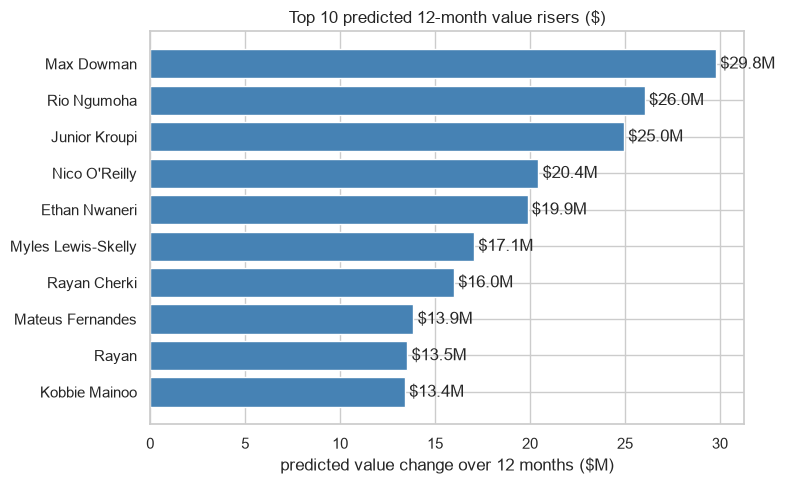

In [9]:
chart_data = all_preds[12].sort_values("predicted_eur_change_usd_m", ascending=False).head(10).sort_values("predicted_eur_change_usd_m")
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(chart_data["name"], chart_data["predicted_eur_change_usd_m"], color="steelblue")
ax.bar_label(bars, fmt="$%.1fM", padding=3)
ax.set_xlabel("predicted value change over 12 months ($M)")
ax.set_title("Top 10 predicted 12-month value risers ($)")
plt.tight_layout()
plt.show()

### How sure is the model? A range around each 12-month prediction

A single number overstates what the model knows. Quantile regression (XGBoost, 10th / 50th / 90th percentile) gives a range instead: walk-forward, the 10-90% band contained the real outcome about three quarters of the time (notebook 05). For the ten biggest predicted 12-month dollar risers above, here is that band in dollar terms.

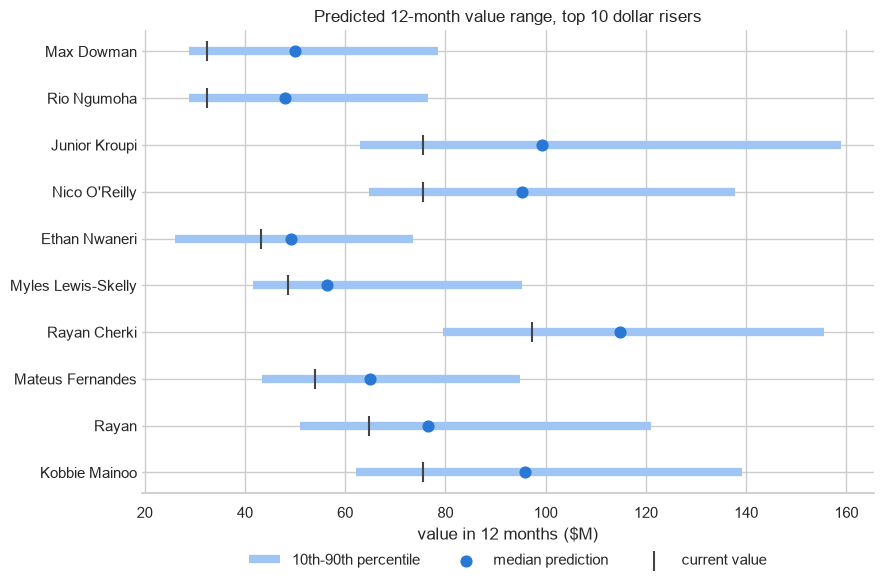

,name,current_usd_m,q10_usd_m,q50_usd_m,q90_usd_m
0,Max Dowman,32.4,28.8,50.0,78.6
1,Rio Ngumoha,32.4,28.8,48.1,76.5
2,Junior Kroupi,75.6,62.9,99.2,158.9
3,Nico O'Reilly,75.6,64.8,95.2,137.8
4,Ethan Nwaneri,43.2,26.1,49.2,73.6
5,Myles Lewis-Skelly,48.6,41.6,56.4,95.2
6,Rayan Cherki,97.2,79.5,114.8,155.5
7,Mateus Fernandes,54.0,43.5,65.0,94.9
8,Rayan,64.8,50.9,76.4,121.0
9,Kobbie Mainoo,75.6,62.2,95.9,139.1


In [10]:
quantile_models = fit_quantile_models(modelable_rows(panel, months=12), months=12, quantiles=(0.1, 0.5, 0.9))
intervals = predict_value_growth_interval(quantile_models, latest)

top_dollar_ids = all_preds[12].sort_values("predicted_eur_change_usd_m", ascending=False).head(10)["player_id"]
band = intervals.set_index("player_id").loc[top_dollar_ids].reset_index()
for q in ("q10", "q50", "q90"):
    band[f"{q}_usd_m"] = band[f"value_eur_{q}"] * USD_PER_EUR / 1_000_000
band["current_usd_m"] = band["current_value_eur"] * USD_PER_EUR / 1_000_000

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(band))[::-1]
ax.hlines(y, band["q10_usd_m"], band["q90_usd_m"], color="#9ec5f4", linewidth=6, label="10th-90th percentile")
ax.scatter(band["q50_usd_m"], y, color="#2a78d6", s=60, zorder=3, label="median prediction")
ax.scatter(band["current_usd_m"], y, color="#444444", marker="|", s=200, zorder=4, label="current value")
ax.set_yticks(y)
ax.set_yticklabels(band["name"])
ax.set_xlabel("value in 12 months ($M)")
ax.set_title("Predicted 12-month value range, top 10 dollar risers")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
sns.despine(ax=ax, left=True)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

band[["name", "current_usd_m", "q10_usd_m", "q50_usd_m", "q90_usd_m"]].round(1)

The bands are wide, and they should be: a typical 10-90% range spans roughly the player's current value. The useful reading is the low end. Where the 10th percentile still sits above today's value, the model is saying a rise is likely under most scenarios; where it sits well below, the headline prediction is a hopeful median over a very uncertain year.